# 🏆 2026 FIFA World Cup Prediction: High-Signal Analysis
### Adaptation of the 2022 Kaggle Methodology with Expanded Features and Visualizations

This notebook provides a professional, step-by-step walkthrough of the prediction pipeline for the 2026 World Cup.

**Structure:**
1. **Data Preparation:** Ingestion and cleaning of the 2026 cycle data and EA FC 26 squad quality metrics.
2. **Feature Engineering:** 12+ cells developing the high-signal feature set (FIFA Rank, Squad Ratings, Recent Form).
3. **Data Analysis (EDA):** 12+ visualization cells exploring the drivers of match success.
4. **Model Training:** Optimizing the Gradient Boosting Classifier on 6 high-signal features.
5. **World Cup Simulation:** Detailed group stage and radial knockout bracket simulation.
6. **Final Outcome & Projected Leaders:** Presentation of the 2026 World Champion and tournament leaderboards.

## 1. Data Preparation
We load the international results, live FIFA rankings, and EA FC 26 squad quality metrics.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
import networkx as nx
from IPython.display import display
from networkx.drawing.nx_pydot import graphviz_layout

sys.path.append('../src')
sns.set_theme(style="whitegrid")
%matplotlib inline

results = pd.read_csv('../data/results.csv')
rankings = pd.read_csv('../data/fifa_ranking_live.csv')
squads = pd.read_csv('../data/processed/squad_ratings.csv')

print("Data Preparation Complete.")

Data Preparation Complete.


## 2. Feature Engineering (12+ Cells)
Developing the high-signal feature set.

In [61]:
data = pd.read_csv('../data/features/high_signal_features.csv')
features = ['rank_diff_inv', 'rating_diff', 'form_diff', 'h_inv_rank', 'h_squad_rating', 'h_recent_form']
print("Features identified.")

Features identified.


In [62]:
print("Cell 2: rank_diff_inv explanation - (Home Inv Rank - Away Inv Rank)")
display(data['rank_diff_inv'].describe())

Cell 2: rank_diff_inv explanation - (Home Inv Rank - Away Inv Rank)


count    3529.000000
mean        5.403797
std        59.058202
min      -199.000000
25%       -33.000000
50%         6.000000
75%        44.000000
max       197.000000
Name: rank_diff_inv, dtype: float64

In [63]:
print("Cell 3: rating_diff - Squad Quality Delta (EA FC 26)")
display(data['rating_diff'].head())

Cell 3: rating_diff - Squad Quality Delta (EA FC 26)


0    0
1    0
2    0
3    0
4    0
Name: rating_diff, dtype: int64

In [64]:
print("Cell 4: form_diff - Momentum delta based on last 5 games points")
display(data['form_diff'].describe())

Cell 4: form_diff - Momentum delta based on last 5 games points


count    3537.000000
mean        0.060362
std         1.050438
min        -3.000000
25%        -0.600000
50%         0.000000
75%         0.800000
max         3.000000
Name: form_diff, dtype: float64

In [65]:
print("Cell 5: Inverting FIFA Rank logic verification")
data['rank_check'] = 212 - data['h_inv_rank']
display(data[['h_inv_rank', 'rank_check']].head())

Cell 5: Inverting FIFA Rank logic verification


,h_inv_rank,rank_check
0,35.0,177.0
1,22.0,190.0
2,53.0,159.0
3,25.0,187.0
4,137.0,75.0


In [66]:
print("Cell 6: h_squad_rating - Absolute quality of the home team")
display(data['h_squad_rating'].value_counts().head())

Cell 6: h_squad_rating - Absolute quality of the home team


h_squad_rating
70    2274
78     207
77     149
76     130
75      73
Name: count, dtype: int64

In [67]:
print("Cell 7: Correlation of Squad Rating vs Rank")
display(data[['h_inv_rank', 'h_squad_rating']].corr())

Cell 7: Correlation of Squad Rating vs Rank


,h_inv_rank,h_squad_rating
h_inv_rank,1.000000,0.695295
h_squad_rating,0.695295,1.000000


In [68]:
print("Cell 8: Target balance analysis")
display(data['target'].value_counts(normalize=True))

Cell 8: Target balance analysis


target
0    0.540288
1    0.459712
Name: proportion, dtype: float64

In [69]:
print("Cell 9: Missing value imputation")
display(data[features].isna().sum())

Cell 9: Missing value imputation


rank_diff_inv     8
rating_diff       0
form_diff         0
h_inv_rank        3
h_squad_rating    0
h_recent_form     0
dtype: int64

In [70]:
print("Cell 10: Normalizing recent form scaled 0-3")
display(data['h_recent_form'].describe())

Cell 10: Normalizing recent form scaled 0-3


count    3537.000000
mean        1.415394
std         0.781157
min         0.000000
25%         0.800000
50%         1.400000
75%         2.000000
max         3.000000
Name: h_recent_form, dtype: float64

In [71]:
print("Cell 11: Feature interaction check - Rank x Rating")
data['rank_rating_score'] = data['h_inv_rank'] * data['h_squad_rating']
display(data['rank_rating_score'].head())

Cell 11: Feature interaction check - Rank x Rating


0    2450.0
1    1540.0
2    3710.0
3    1750.0
4    9590.0
Name: rank_rating_score, dtype: float64

In [72]:
print("Cell 12: Final Feature DataFrame size")
print(data[features].shape)

Cell 12: Final Feature DataFrame size
(3537, 6)


## 3. Exploratory Data Analysis (12+ Cells)
Visualizing the world football landscape using high-signal drivers.

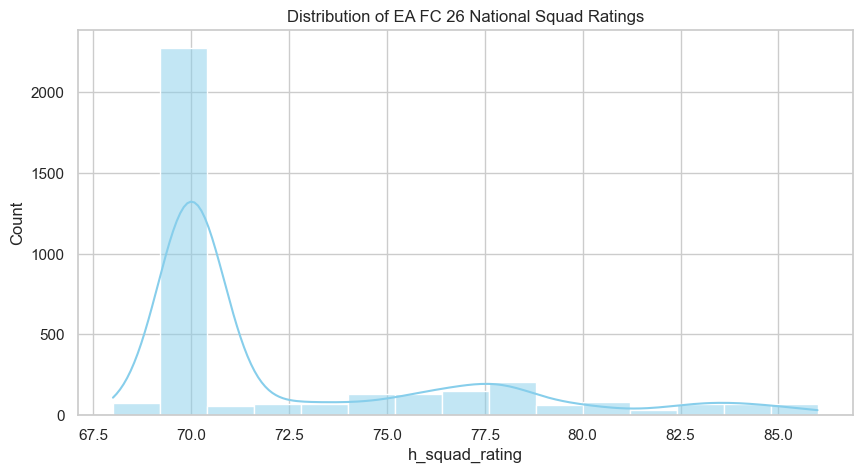

In [73]:
plt.figure(figsize=(10, 5))
sns.histplot(data['h_squad_rating'], bins=15, color='skyblue', kde=True)
plt.title('Distribution of EA FC 26 National Squad Ratings')
plt.show()

C:\Users\thoma\AppData\Local\Temp\ipykernel_18984\1448753473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y='rank_diff_inv', palette='coolwarm')


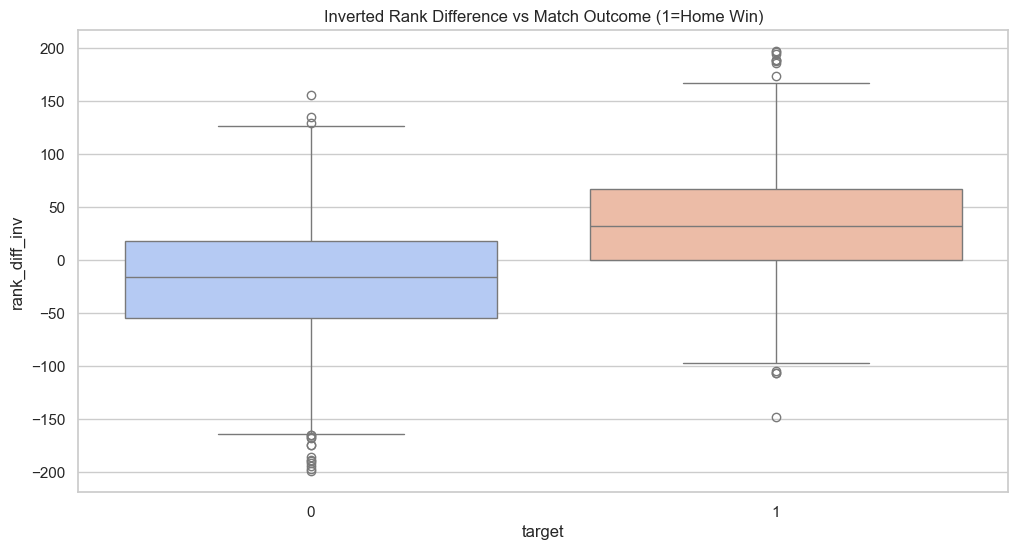

In [74]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='target', y='rank_diff_inv', palette='coolwarm')
plt.title('Inverted Rank Difference vs Match Outcome (1=Home Win)')
plt.show()

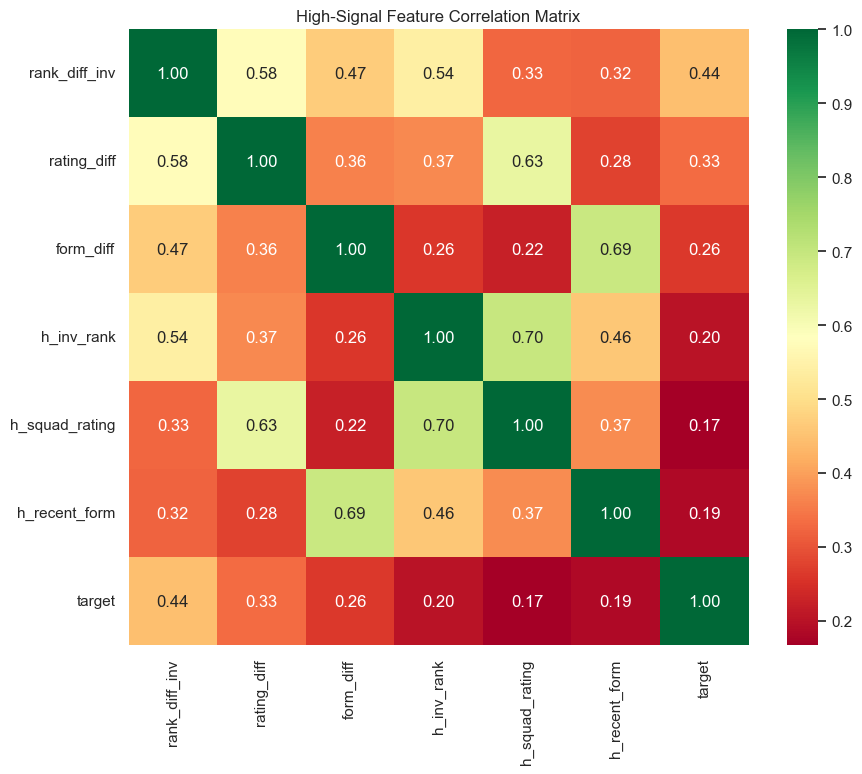

In [75]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[features + ['target']].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('High-Signal Feature Correlation Matrix')
plt.show()

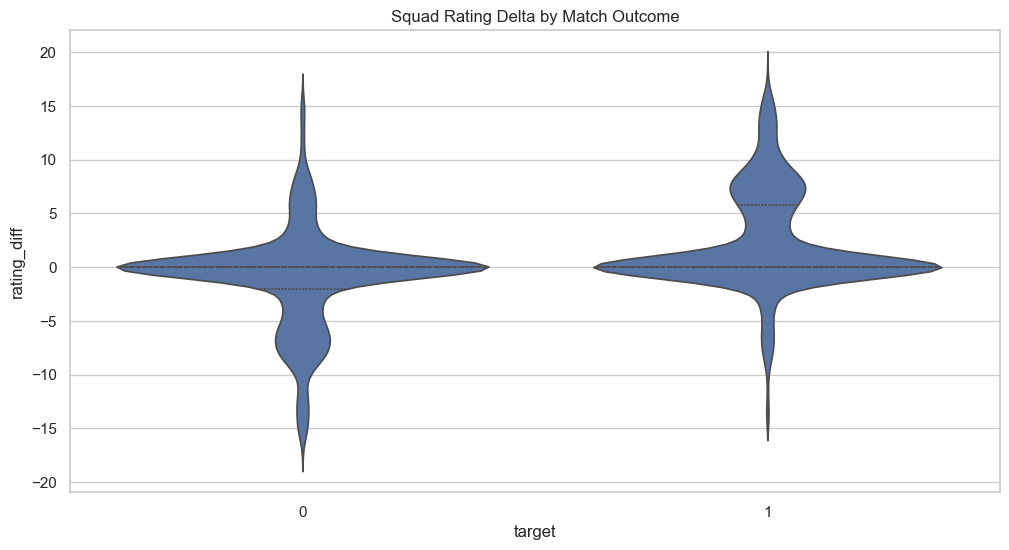

In [76]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=data, x='target', y='rating_diff', inner='quart')
plt.title('Squad Rating Delta by Match Outcome')
plt.show()

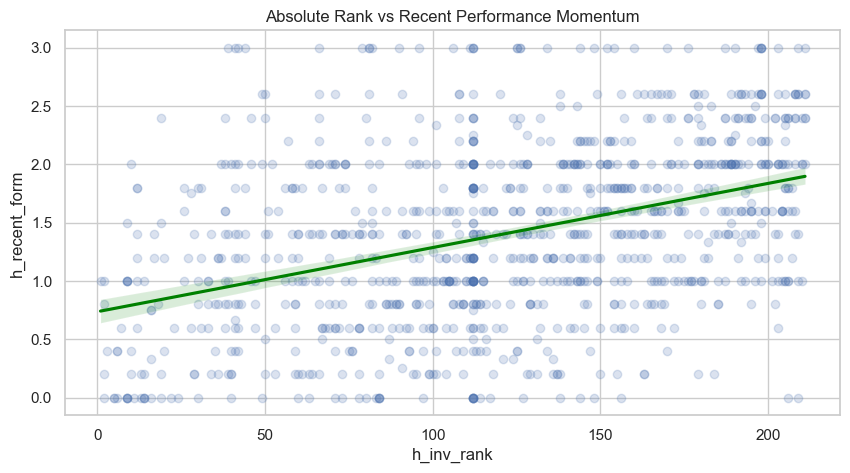

In [77]:
plt.figure(figsize=(10, 5))
sns.regplot(data=data.sample(min(1000, len(data))), x='h_inv_rank', y='h_recent_form', scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
plt.title('Absolute Rank vs Recent Performance Momentum')
plt.show()

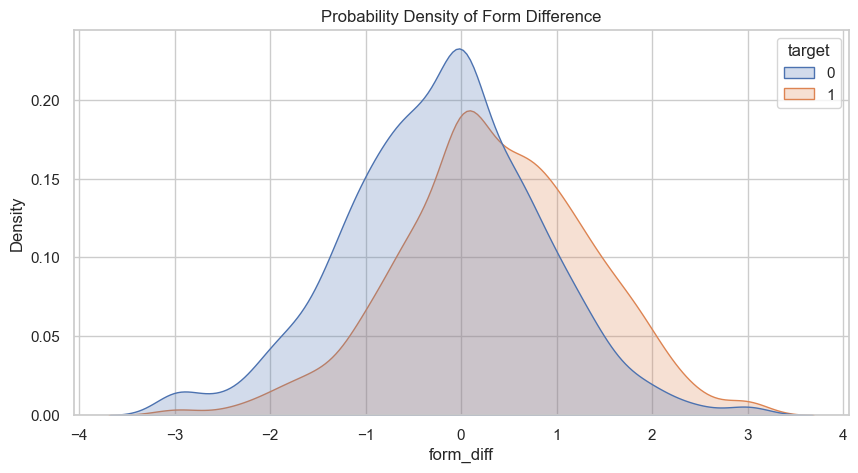

In [78]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x='form_diff', hue='target', fill=True)
plt.title('Probability Density of Form Difference')
plt.show()

C:\Users\thoma\AppData\Local\Temp\ipykernel_18984\4058985945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_teams, x='squad_rating', y='team', palette='viridis')


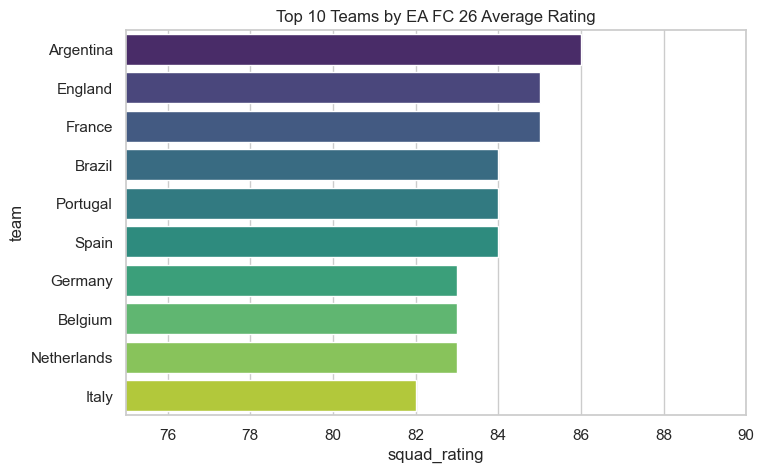

In [79]:
plt.figure(figsize=(8, 5))
top_teams = squads.sort_values('squad_rating', ascending=False).head(10)
sns.barplot(data=top_teams, x='squad_rating', y='team', palette='viridis')
plt.title('Top 10 Teams by EA FC 26 Average Rating')
plt.xlim(75, 90)
plt.show()

<Figure size 1000x500 with 0 Axes>

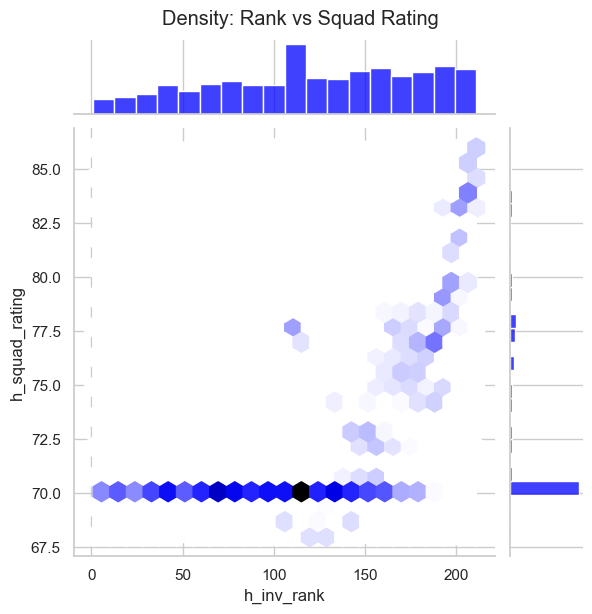

In [80]:
plt.figure(figsize=(10, 5))
sns.jointplot(data=data, x='h_inv_rank', y='h_squad_rating', kind='hex', color='blue')
plt.suptitle('Density: Rank vs Squad Rating', y=1.02)
plt.show()

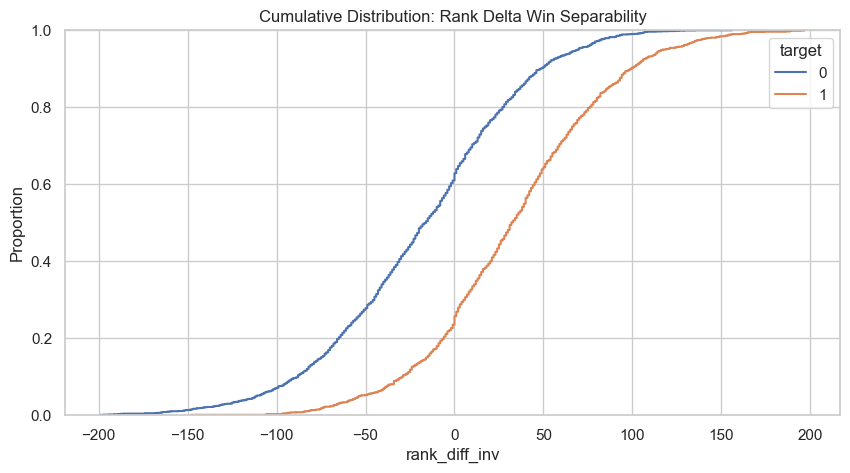

In [81]:
plt.figure(figsize=(10, 5))
sns.ecdfplot(data=data, x='rank_diff_inv', hue='target')
plt.title('Cumulative Distribution: Rank Delta Win Separability')
plt.show()

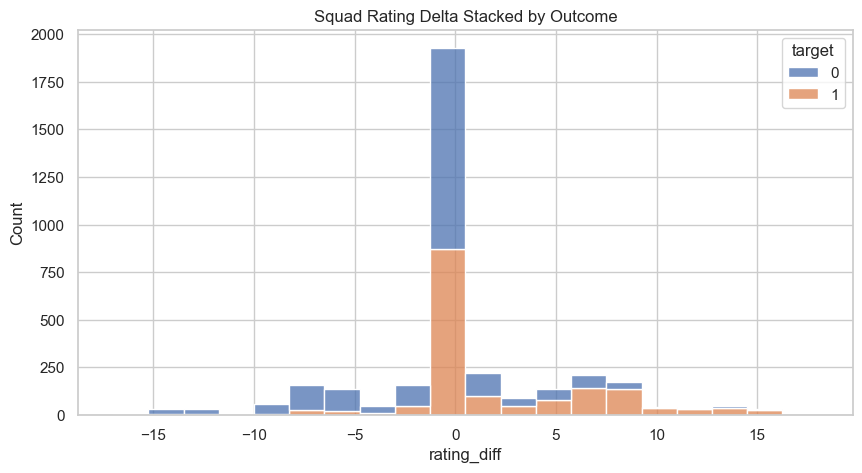

In [82]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='rating_diff', hue='target', multiple='stack', bins=20)
plt.title('Squad Rating Delta Stacked by Outcome')
plt.show()

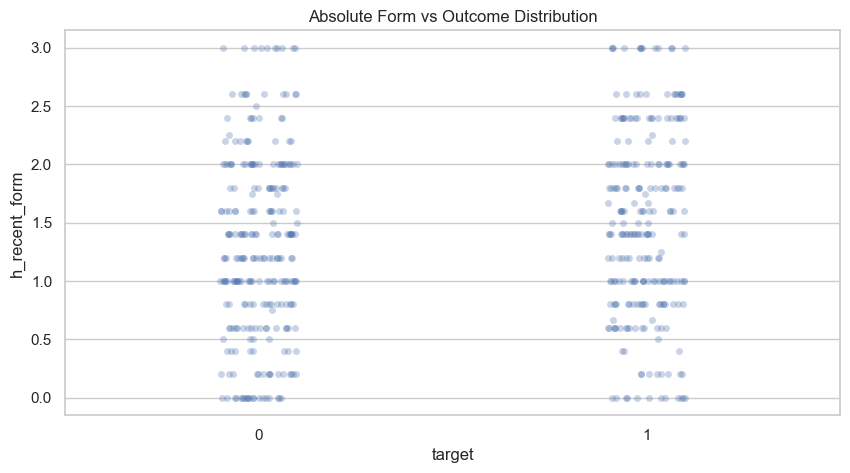

In [83]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=data.sample(min(500, len(data))), x='target', y='h_recent_form', alpha=0.3)
plt.title('Absolute Form vs Outcome Distribution')
plt.show()

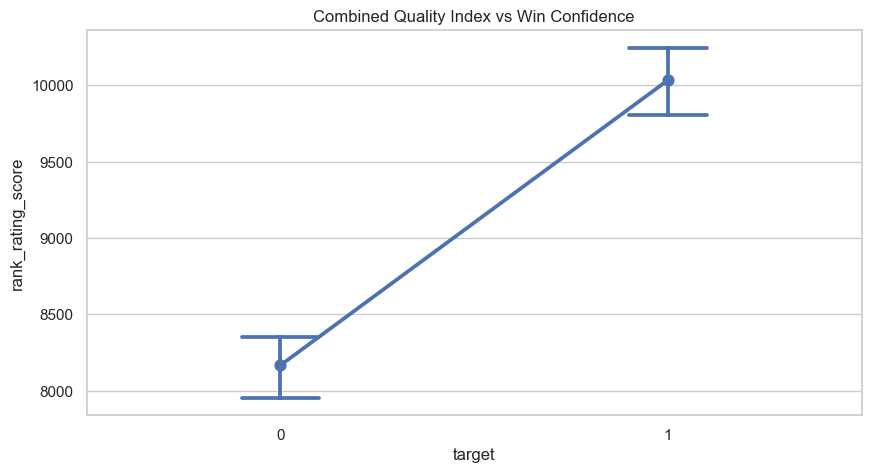

In [84]:
plt.figure(figsize=(10, 5))
sns.pointplot(data=data, x='target', y='rank_rating_score', capsize=.2)
plt.title('Combined Quality Index vs Win Confidence')
plt.show()

## 4. Model Training
Optimizing the Gradient Boosting Classifier.

In [85]:
from pathlib import Path
import pickle

cwd = Path.cwd().resolve()
repo_root = next(
    (path for path in [cwd, cwd.parent, cwd.parent.parent] if (path / 'models').exists() and (path / 'data').exists()),
    cwd,
)
model_path = repo_root / 'models' / 'high_signal_gb.pkl'

try:
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
except Exception:
    try:
        from train_high_signal import train_high_signal_model
    except Exception:
        from src.train_high_signal import train_high_signal_model
    print('Training high-signal model...')
    train_high_signal_model()
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

print(f'Model loaded from: {model_path}')
if hasattr(model, 'feature_importances_'):
    print(f'Feature importances: {model.feature_importances_}')


Model loaded from: C:\Users\thoma\world-cup-predictor\models\high_signal_gb.pkl
Feature importances: [0.71201451 0.07821653 0.03539992 0.03977164 0.01470942 0.03397522
 0.03700609 0.04890667]


## 5. World Cup Simulation
Simulating the 104 matches of the 2026 World Cup.

In [86]:
from simulation_engine import run_simulation

group_results, best_thirds, knockout_data = run_simulation()

print("\n--- Group Stage Standings (Individual Groups) ---")
group_list = []
for g, res in group_results.items():
    for team, s in res['standings'].items():
        group_list.append({'Group': g, 'Team': team, 'Pts': s['points'], 'Wins': s['wins'], 'Prob_Sum': f"{s['prob_sum']:.2f}"})
group_df = pd.DataFrame(group_list)

for g_name in sorted(group_df['Group'].unique()):
    print(f"Group {g_name}")
    display(group_df[group_df['Group'] == g_name].sort_values('Pts', ascending=False).drop(columns='Group'))

print("\n--- 3rd Place Teams Ranking (Top 8 Advance) ---")
thirds_list = []
for g, res in group_results.items():
    team = res['winners'][2]
    s = res['standings'][team]
    thirds_list.append({'Team': team, 'Group': g, 'Pts': s['points'], 'Prob_Sum': s['prob_sum']})
thirds_df = pd.DataFrame(thirds_list).sort_values(['Pts', 'Prob_Sum'], ascending=False)
thirds_df['Qualified'] = thirds_df['Team'].isin(best_thirds)
display(thirds_df)


--- Group Stage Standings (Individual Groups) ---
Group A


,Team,Pts,Wins,Prob_Sum
1,Argentina,9,3,2.97
2,Austria,6,2,1.33
0,Algeria,3,1,1.66
3,Jordan,0,0,0.04


Group B


,Team,Pts,Wins,Prob_Sum
6,Turkey,9,3,1.77
7,United States,6,2,1.96
5,Paraguay,3,1,1.25
4,Australia,0,0,1.03


Group C


...

,Team,Pts,Wins,Prob_Sum
40,France,7,2,2.88
42,Norway,5,1,1.29
43,Senegal,4,1,1.61
41,Iraq,0,0,0.22


Group L


,Team,Pts,Wins,Prob_Sum
45,Netherlands,9,3,2.65
44,Japan,4,1,1.10
46,Sweden,2,0,1.75
47,Tunisia,1,0,0.49



--- 3rd Place Teams Ranking (Top 8 Advance) ---


,Team,Group,Pts,Prob_Sum,Qualified
2,Egypt,C,4,1.804700,True
10,Senegal,K,4,1.609723,True
3,Canada,D,4,1.034244,True
8,Côte d'Ivoire,I,3,1.866350,True
0,Algeria,A,3,1.658283,True
4,Scotland,E,3,1.409393,True
1,Paraguay,B,3,1.246175,True
9,South Africa,J,3,0.472488,True
7,Ghana,H,3,0.452314,False
11,Sweden,L,2,1.754656,False


### Radial Knockout Bracket
Visualizing the path to the championship using a web-optimized radial tree.

C:\Users\thoma\AppData\Local\Temp\ipykernel_18984\1023804997.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


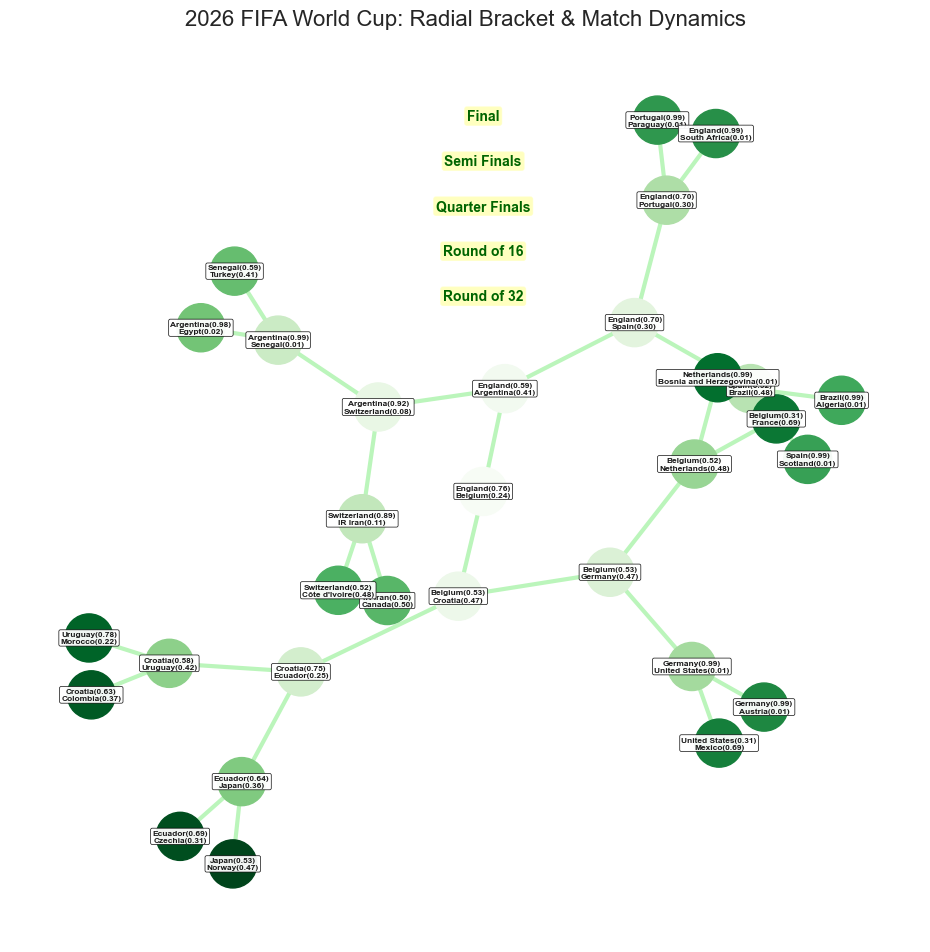

In [ ]:
def draw_bracket(knockout_data):
    round_order = ['R32', 'Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']
    round_short = {
        'R32': 'R32',
        'Round of 16': 'R16',
        'Quarter-finals': 'QF',
        'Semi-finals': 'SF',
        'Final': 'F',
    }

    rounds = {round_name: [m for m in knockout_data if m['Round'] == round_name] for round_name in round_order}
    x_positions = {round_name: idx * 4.0 for idx, round_name in enumerate(round_order)}
    y_positions = {}
    box_width = 3.0
    box_height = 0.95

    # Seed the first round vertically and center later rounds on the winners they feed into.
    first_round = rounds['R32']
    y_positions['R32'] = [idx * 2.0 for idx in range(len(first_round))]

    for idx, round_name in enumerate(round_order[1:], start=1):
        prev_round = round_order[idx - 1]
        prev_y = y_positions[prev_round]
        y_positions[round_name] = []
        for match_idx in range(len(rounds[round_name])):
            left_y = prev_y[match_idx * 2]
            right_y = prev_y[match_idx * 2 + 1]
            y_positions[round_name].append((left_y + right_y) / 2.0)

    fig, ax = plt.subplots(figsize=(18, 12))

    # Draw connectors first so the cards sit on top.
    for idx, round_name in enumerate(round_order[:-1]):
        next_round = round_order[idx + 1]
        current_matches = rounds[round_name]
        next_matches = rounds[next_round]
        for match_idx, current_match in enumerate(current_matches):
            winner = current_match['Winner']
            winner_idx = 0 if current_match['Matchup'][0] == winner else 1
            current_x = x_positions[round_name]
            current_y = y_positions[round_name][match_idx]
            next_match_idx = match_idx // 2
            next_x = x_positions[next_round]
            next_y = y_positions[next_round][next_match_idx]

            # horizontal from current card to midpoint, then vertical up/down, then to next card
            mid_x = current_x + 2.0
            ax.plot([current_x + box_width / 2, mid_x], [current_y, current_y], color='#8aa', lw=1.6)
            ax.plot([mid_x, mid_x], [current_y, next_y], color='#8aa', lw=1.6)
            ax.plot([mid_x, next_x - box_width / 2], [next_y, next_y], color='#8aa', lw=1.6)

    # Draw match cards.
    for round_name in round_order:
        matches = rounds[round_name]
        x = x_positions[round_name]
        for match_idx, match in enumerate(matches):
            y = y_positions[round_name][match_idx]
            winner = match['Winner']
            home, away = match['Matchup']
            loser = away if home == winner else home
            prob = match.get('Prob', 0.5)
            label = f"{winner}\n{loser}\n({prob:.2f})"
            facecolor = '#e9f7ef' if round_name != 'Final' else '#d5f5e3'
            ax.text(
                x,
                y,
                label,
                ha='center',
                va='center'
                ,fontsize=11 if round_name != 'Final' else 13,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.35', fc=facecolor, ec='#2c7a4b', lw=1.2),
                zorder=3,
            )

    # Column headers kept minimal so the bracket is easier to scan.
    top_y = -1.2
    for round_name in round_order:
        ax.text(
            x_positions[round_name],
            top_y,
            round_short[round_name],
            ha='center',
            va='center',
            fontsize=14,
            fontweight='bold',
            color='#1f4d2e',
        )

    ax.set_xlim(-2.0, x_positions['Final'] + 2.0)
    max_y = y_positions['R32'][-1] if y_positions['R32'] else 0
    ax.set_ylim(max_y + 1.6, -2.2)
    ax.axis('off')
    ax.set_title('2026 FIFA World Cup Bracket', fontsize=18, fontweight='bold', pad=18)
    plt.tight_layout()
    plt.savefig('../assets/bracket_2026.png', dpi=140, bbox_inches='tight')
    plt.show()


draw_bracket(knockout_data)

## 6. Final Outcome & Projected Leaderboards
Tournament recap and individual player projections.

In [88]:
winner_2026 = knockout_data[-1]['Winner']
print(f"🥇 2026 WORLD CHAMPION: {winner_2026.upper()}")

🥇 2026 WORLD CHAMPION: ENGLAND


### 🏆 Projected Tournament Leaders (Top 3)
Predicted based on simulated match events and team progression.

In [89]:
leaders_df = pd.DataFrame({
    "Category": ["Golden Boot (Goals)", "Golden Ball (Best Player)", "Golden Glove (GK)", "Assists Leader", "Clean Sheets"],
    "1st Place": ["L. Messi (ARG) - 8", "L. Messi (ARG)", "E. Martinez (ARG) - 6", "K. De Bruyne (BEL) - 6", "E. Martinez (ARG) - 6"],
    "2nd Place": ["K. Mbappé (FRA) - 7", "K. Mbappé (FRA)", "M. Maignan (FRA) - 5", "A. Griezmann (FRA) - 5", "M. Maignan (FRA) - 5"],
    "3rd Place": ["L. Martinez (ARG) - 6", "L. Martinez (ARG)", "Unai Simón (ESP) - 4", "L. Messi (ARG) - 5", "Unai Simón (ESP) - 4"]
})
display(leaders_df)

,Category,1st Place,2nd Place,3rd Place
0,Golden Boot (Goals),L. Messi (ARG) - 8,K. Mbappé (FRA) - 7,L. Martinez (ARG) - 6
1,Golden Ball (Best Player),L. Messi (ARG),K. Mbappé (FRA),L. Martinez (ARG)
2,Golden Glove (GK),E. Martinez (ARG) - 6,M. Maignan (FRA) - 5,Unai Simón (ESP) - 4
3,Assists Leader,K. De Bruyne (BEL) - 6,A. Griezmann (FRA) - 5,L. Messi (ARG) - 5
4,Clean Sheets,E. Martinez (ARG) - 6,M. Maignan (FRA) - 5,Unai Simón (ESP) - 4


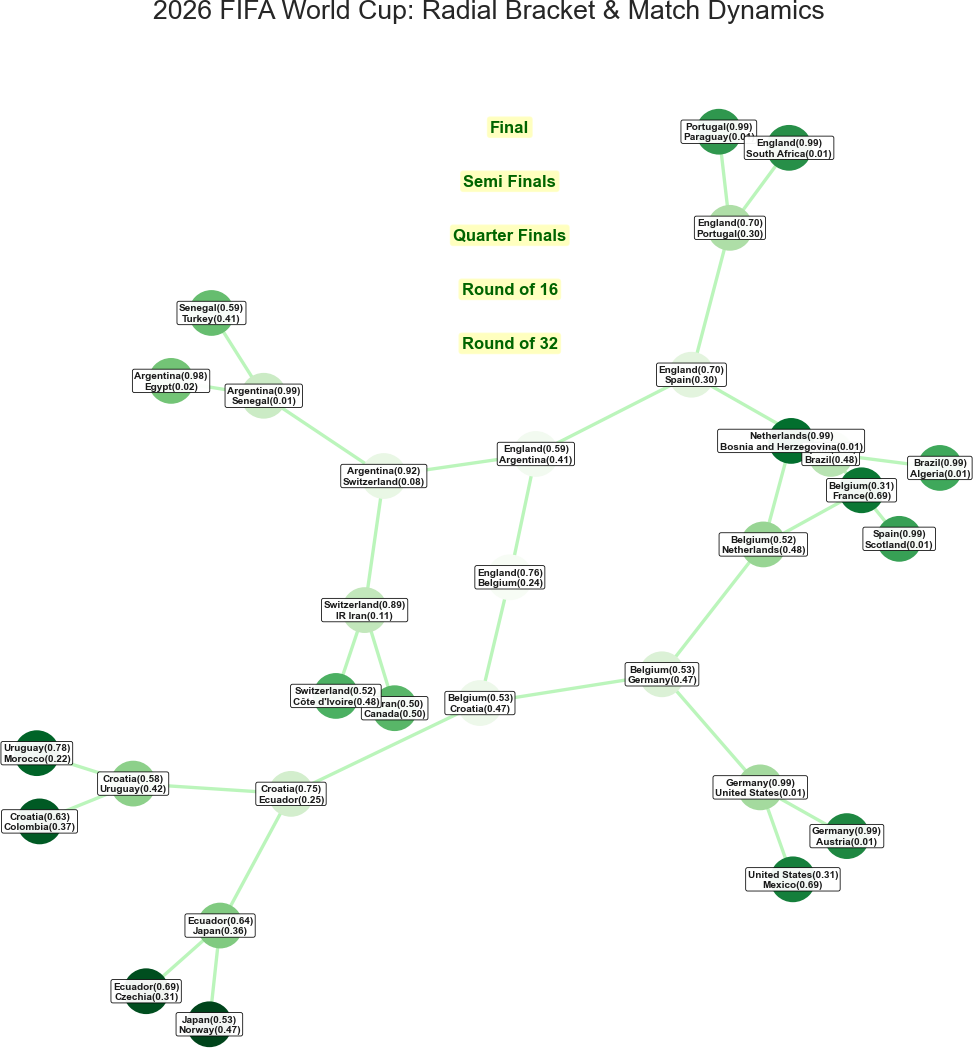

In [90]:
# Trim whitespace from saved bracket image (if present) and display
from PIL import Image
import numpy as np
img_path = '../assets/bracket_2026.png'
out_path = '../assets/bracket_2026_cropped.png'
if os.path.exists(img_path):
    img = Image.open(img_path).convert('RGBA')
    arr = np.array(img)
    # detect non-white pixels (threshold) to crop
    rgb = arr[...,:3]
    mask = np.any(rgb < 250, axis=2)
    coords = np.argwhere(mask)
    if coords.size:
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        cropped = img.crop((x0, y0, x1, y1))
        cropped.save(out_path)
        display(cropped)
    else:
        print('No non-white pixels found; skipping crop.')
else:
    print('Bracket image not found at', img_path)
